## Kode Tugas 1
Dhimas Putra Sulistio (24/537952/PA/22811)

### Daftar Revisi yang Dilakukan
* **Otomatisasi Pemisahan Dataset (*Dataset Splitting*):** Melakukan pembagian dataset ke dalam data *training* dan *validation* secara terprogram (*fully by code*) tanpa proses manual.
* **Modularisasi Kode (*Reusable Functions*):** Mengimplementasikan fungsi yang dapat digunakan kembali (*reusable functions*) untuk operasi-operasi yang berulang guna meningkatkan modularitas dan keterbacaan kode.
* **Penyesuaian Skala Sumbu Vertikal pada Grafik:** Memperbaiki dan menstandardisasi skala sumbu vertikal (sumbu-y) pada visualisasi grafik (khususnya rentang 0%–100% pada grafik akurasi) agar interpretasi data lebih proporsional dan akurat.
* **Visualisasi Komparasi Terpadu:** Menyajikan grafik komparasi gabungan antara data *training* dan *validation* dalam satu kanvas plot untuk mempermudah evaluasi dan perbandingan performa model.

In [ ]:
import pandas as pd
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# DATASET
dataset = pd.read_csv('dataset.csv')

# Splitting dataset secara otomatis
df = pd.concat([dataset.iloc[0:40], dataset.iloc[50:90]]).reset_index(drop=True)
df1 = pd.concat([dataset.iloc[40:50], dataset.iloc[90:100]]).reset_index(drop=True)

# ==================== FUNGSI OPERASI PERSEPTRON ====================
def calculate_z(x1, x2, x3, x4, teta1, teta2, teta3, teta4, bias):
    """Menghitung kombinasi linier input, bobot, dan bias (z)."""
    return (x1 * teta1) + (x2 * teta2) + (x3 * teta3) + (x4 * teta4) + bias

def calculate_sigmoid(z):
    """Menghitung fungsi aktivasi sigmoid 1 / (1 + e^(-z))."""
    return 1 / (1 + math.exp(-z))

def calculate_square_error(sigmoid, target):
    """Menghitung square error (sigmoid - target)^2."""
    return pow((sigmoid - target), 2)

def calculate_prediction(sigmoid, threshold=0.5):
    """Menghitung prediksi biner (1 jika sigmoid > 0.5, selain itu 0)."""
    return 1 if sigmoid > threshold else 0

def calculate_deltas(x1, x2, x3, x4, sigmoid, target):
    """Menghitung delta error / gradien untuk update bias dan bobot."""
    delta = 2 * (sigmoid - target) * (1 - sigmoid) * sigmoid
    dbias = delta
    dteta1 = delta * x1
    dteta2 = delta * x2
    dteta3 = delta * x3
    dteta4 = delta * x4
    return dbias, dteta1, dteta2, dteta3, dteta4
# ===================================================================

learning_rate = 0.1
bias = teta1 = teta2 = teta3 = teta4 = 0.5
dbias = dteta1 = dteta2 = dteta3 = dteta4 = 0

mse_data = []
accuracy_data = []
mse_val_data = []
accuracy_val_data = []

for epoch in range(5):
    sum_square_error = 0
    correct_counter = 0
    
    # TRAINING
    for i in range(len(df)):
        x1 = df.loc[i, 'X1']
        x2 = df.loc[i, 'X2']
        x3 = df.loc[i, 'X3']
        x4 = df.loc[i, 'X4']
        target = df.loc[i, 'TARGET']
        
        z = calculate_z(x1, x2, x3, x4, teta1, teta2, teta3, teta4, bias)
        sigmoid = calculate_sigmoid(z)
        sum_square_error += calculate_square_error(sigmoid, target)

        prediction = calculate_prediction(sigmoid)
        if prediction == target:
            correct_counter += 1
        
        dbias, dteta1, dteta2, dteta3, dteta4 = calculate_deltas(x1, x2, x3, x4, sigmoid, target)

        bias -= learning_rate * dbias
        teta1 -= learning_rate * dteta1
        teta2 -= learning_rate * dteta2
        teta3 -= learning_rate * dteta3
        teta4 -= learning_rate * dteta4

    # VALIDATION
    sum_square_error_val = 0
    val_correct_counter = 0
    for i in range(len(df1)):
        x1 = df1.loc[i, 'X1']
        x2 = df1.loc[i, 'X2']
        x3 = df1.loc[i, 'X3']
        x4 = df1.loc[i, 'X4']
        target = df1.loc[i, 'TARGET']
        
        z = calculate_z(x1, x2, x3, x4, teta1, teta2, teta3, teta4, bias)
        sigmoid = calculate_sigmoid(z)
        sum_square_error_val += calculate_square_error(sigmoid, target)

        prediction = calculate_prediction(sigmoid)
        if prediction == target:
            val_correct_counter += 1

    mse = sum_square_error / len(df)
    mse_val = sum_square_error_val / len(df1)
    mse_data.append(mse)
    mse_val_data.append(mse_val)

    accuracy_data.append((correct_counter, (correct_counter / len(df)) * 100))
    accuracy_val_data.append((val_correct_counter, (val_correct_counter / len(df1)) * 100))


print("========MSE TRAINING========")
for i in range(len(mse_data)):
    print("Epoch ", i + 1, " : ", mse_data[i])

print("======ACCURACY TRAINING======")
for i in range(len(accuracy_data)):
    print("Epoch ", i + 1, " : ", accuracy_data[i][1], "%")

print("======MSE VALIDATION======")
for i in range(len(mse_val_data)):
    print("Epoch ", i + 1, " : ", mse_val_data[i])

print("======ACCURACY VALIDATION======")
for i in range(len(accuracy_val_data)):
    print("Epoch ", i + 1, " : ", accuracy_val_data[i][1], "%")


========MSE TRAINING========
Epoch  1  :  0.4498886551395292
Epoch  2  :  0.0374519142280995
Epoch  3  :  0.02437219499639377
Epoch  4  :  0.0173572016784266
Epoch  5  :  0.012740158208926562
======ACCURACY TRAINING======
Epoch  1  :  52.5 %
Epoch  2  :  95.0 %
Epoch  3  :  97.5 %
Epoch  4  :  97.5 %
Epoch  5  :  98.75 %
======MSE VALIDATION======
Epoch  1  :  0.3289511565546991
Epoch  2  :  0.24728932330356232
Epoch  3  :  0.17589164066713475
Epoch  4  :  0.11938137329297324
Epoch  5  :  0.08158136941106596
======ACCURACY VALIDATION======
Epoch  1  :  50.0 %
Epoch  2  :  50.0 %
Epoch  3  :  50.0 %
Epoch  4  :  85.0 %
Epoch  5  :  100.0 %


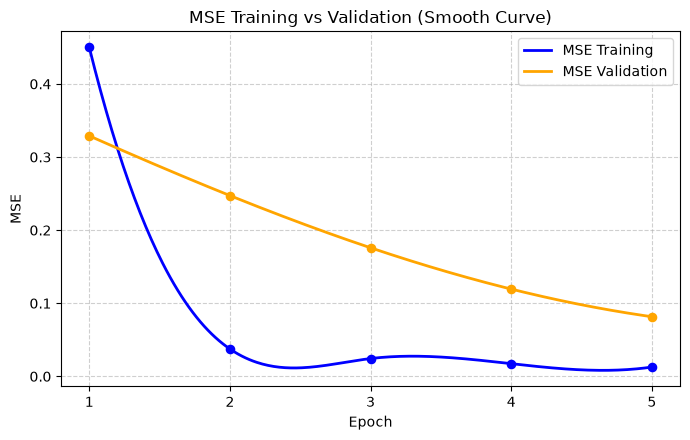

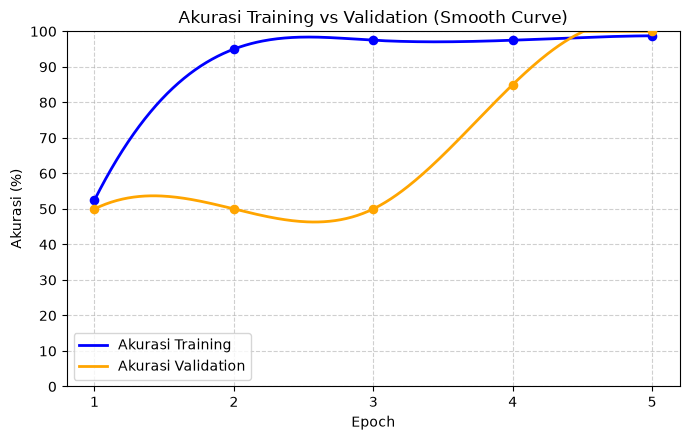

In [3]:
epochs = np.array(range(1, len(mse_data) + 1))
train_acc = np.array([acc[1] for acc in accuracy_data])
val_acc = np.array([acc[1] for acc in accuracy_val_data])
train_mse = np.array(mse_data)
val_mse = np.array(mse_val_data)

# Fungsi pembantu untuk membuat kurva halus (smooth spline)
def smooth_curve(x, y, num_points=300):
    x_smooth = np.linspace(x.min(), x.max(), num_points)
    spline = make_interp_spline(x, y, k=3)
    y_smooth = spline(x_smooth)
    return x_smooth, y_smooth

# 1. Plot Gabungan: MSE Training & Validation
x_tr, y_tr = smooth_curve(epochs, train_mse)
x_vl, y_vl = smooth_curve(epochs, val_mse)
plt.figure(figsize=(7, 4.5))
plt.plot(x_tr, y_tr, color='blue', linewidth=2, label='MSE Training')
plt.scatter(epochs, train_mse, color='blue', s=35, zorder=5)
plt.plot(x_vl, y_vl, color='orange', linewidth=2, label='MSE Validation')
plt.scatter(epochs, val_mse, color='orange', s=35, zorder=5)
plt.title('MSE Training vs Validation (Smooth Curve)')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.xticks(epochs)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# 2. Plot Gabungan: Akurasi Training & Validation (Skala vertikal 0% - 100%)
x_tr, y_tr = smooth_curve(epochs, train_acc)
x_vl, y_vl = smooth_curve(epochs, val_acc)
plt.figure(figsize=(7, 4.5))
plt.plot(x_tr, np.clip(y_tr, 0, 100), color='blue', linewidth=2, label='Akurasi Training')
plt.scatter(epochs, train_acc, color='blue', s=35, zorder=5)
plt.plot(x_vl, np.clip(y_vl, 0, 100), color='orange', linewidth=2, label='Akurasi Validation')
plt.scatter(epochs, val_acc, color='orange', s=35, zorder=5)
plt.title('Akurasi Training vs Validation (Smooth Curve)')
plt.xlabel('Epoch')
plt.ylabel('Akurasi (%)')
plt.ylim(0, 100)
plt.xticks(epochs)
plt.yticks(range(0, 101, 10))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()
